In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import platform
import time
import pathlib
import os

print('Python version:', platform.python_version())
print('Tensorflow version:', tf.__version__)
print('Keras version:', tf.keras.__version__)

Python version: 3.11.12
Tensorflow version: 2.18.0
Keras version: 3.8.0


In [5]:
!pip install numpy
!pip install gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 83.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 110.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 15.6 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.15.3
    Uninstalling scipy-1.15.3:
      Successfully uninstalled scipy-1.15.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tsfresh 0.21.0 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.13.1 which is incompatible.
thinc 8.3.6 re

In [2]:
import gensim
from gensim.models import Word2Vec
from collections import Counter

In [3]:
from google.colab import drive
drive.mount('/content/drive')
dataset_file_path = '/content/drive/MyDrive/Colab Notebooks/sherlockholmes.txt'

cache_dir = './tmp'
dataset_file_name = 'sherlockholmes.txt'


print(dataset_file_path)

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks/sherlockholmes.txt


In [5]:
text = open(dataset_file_path, mode='r').read()
print(text[:250])

The Adventures of Sherlock Holmes

by Arthur Conan Doyle

I. A SCANDAL IN BOHEMIA


I.

To Sherlock Holmes she is always _the_ woman. I have seldom heard him
mention her under any other name. In his eyes she eclipses and
predominates the whole of her


In [6]:
from transformers import GPT2Tokenizer
from tokenizers import ByteLevelBPETokenizer

In [7]:
tokenizer = ByteLevelBPETokenizer()
save_dir="./tokenizer"

tokenizer.train(files=[dataset_file_path], vocab_size=30_000, min_frequency=2)

if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# Save the tokenizer model
tokenizer.save_model(save_dir)

# Load the tokenizer using GPT2Tokenizer
custom_tokenizer = GPT2Tokenizer.from_pretrained(save_dir)



Tokenize the text file

In [8]:
input_ids = custom_tokenizer.encode(text)
print(f"Total tokens in text: {len(input_ids)}")

Total tokens in text: 148854


In [9]:
def simple_tokenize(text):
    import re
    # Tokenize words and punctuation separately
    tokens = re.findall(r"\w+|[^\w\s]", text.lower())
    return tokens

# Tokenize the entire text and create vocabulary
tokens = simple_tokenize(text)
print(f"Total tokens in text: {len(tokens)}")

Total tokens in text: 132163


In [10]:
# Create word2vec model
# Window size controls how many words before and after to include as context
# Min_count filters out rare words
# Size defines the dimension of word vectors
word2vec_model2 = Word2Vec(sentences=[tokens], vector_size=256, window=5, min_count=2, workers=4)
word2vec_model2.train([tokens], total_examples=1, epochs=10,start_alpha=0.001, end_alpha=0.0001)

(100000, 1321630)

In [54]:
import gensim.downloader as api
word2vec_model = api.load("glove-wiki-gigaword-50")  # smaller and faster to load

[==================================================] 100.0% 66.0/66.0MB downloaded


In [55]:
# Create vocabulary and word indices
word_counts = Counter(tokens)
vocab = sorted(word_counts, key=word_counts.get, reverse=True)
vocab_size = len(vocab) + 1  # +1 for out-of-vocabulary tokens

# Create lookup dictionaries
word_to_index = {word: i+1 for i, word in enumerate(vocab)}  # Start from 1, reserve 0 for OOV
index_to_word = {i+1: word for i, word in enumerate(vocab)}
# Add OOV token
word_to_index['<OOV>'] = 0
index_to_word[0] = '<OOV>'

# Convert tokens to indices
input_ids = [word_to_index.get(token, 0) for token in tokens]
print(f"Total indexed tokens: {len(input_ids)}")


Total indexed tokens: 132163


In [57]:
embedding_dim = 50  # Same as word2vec dimension
embedding_matrix = np.zeros((vocab_size, embedding_dim))
unknown_words = 0
t=0

# Fill embedding matrix with word2vec vectors
for word, i in word_to_index.items():
    t+=1
    if word in word2vec_model:
        embedding_matrix[i] = word2vec_model[word]
    else:
        # For OOV words, initialize randomly
        embedding_matrix[i] = np.random.normal(scale=0.6, size=(embedding_dim,))
        unknown_words+=1
print(unknown_words/len(word_to_index))

0.025750549182328532


Prepping data

In [58]:
tokens_dataset = tf.data.Dataset.from_tensor_slices(input_ids)

In [59]:
sequence_length = 100
examples_per_epoch = len(input_ids) // (sequence_length + 1)

print(f'Examples per epoch: {examples_per_epoch}')


Examples per epoch: 1308


In [60]:
# Generate batched sequences out of the token dataset
sequences = tokens_dataset.batch(sequence_length + 1, drop_remainder=True)

In [61]:
# Split sequences into input and target
def split_input_target(chunk):
    input_text = chunk[:-1]
    target_text = chunk[1:]
    return input_text, target_text

dataset = sequences.map(split_input_target)

In [62]:
# Show some examples of input-target pairs
for input_example, target_example in dataset.take(1):
    for i in range(5):
        if i < len(input_example):
            input_token = input_example[i].numpy()
            target_token = target_example[i].numpy()
            print(f'Step {i:2d}')
            print(f'  input token: {input_token} ({index_to_word.get(input_token, "<OOV>")})')
            print(f'  expected output token: {target_token} ({index_to_word.get(target_token, "<OOV>")})')

Step  0
  input token: 3 (the)
  expected output token: 1418 (adventures)
Step  1
  input token: 1418 (adventures)
  expected output token: 8 (of)
Step  2
  input token: 8 (of)
  expected output token: 142 (sherlock)
Step  3
  input token: 142 (sherlock)
  expected output token: 40 (holmes)
Step  4
  input token: 40 (holmes)
  expected output token: 55 (by)


In [63]:
# Batch size.
BATCH_SIZE = 64

# Buffer size to shuffle the dataset (TF data is designed to work
# with possibly infinite sequences, so it doesn't attempt to shuffle
# the entire sequence in memory. Instead, it maintains a buffer in
# which it shuffles elements).
BUFFER_SIZE = 10000

dataset = dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE, drop_remainder=True)

dataset

<_BatchDataset element_spec=(TensorSpec(shape=(64, 100), dtype=tf.int32, name=None), TensorSpec(shape=(64, 100), dtype=tf.int32, name=None))>

In [64]:
print('Batched dataset size: {}'.format(len(list(dataset.as_numpy_iterator()))))

Batched dataset size: 20


In [65]:
# The embedding dimension
embedding_dim = 50

# Number of RNN units
rnn_units = 1024

In [66]:
print(embedding_matrix.shape[0], vocab_size)

8194 8194


In [67]:
def build_model(vocab_size, embedding_dim, rnn_units, batch_size, embedding_matrix=None):
    model = tf.keras.models.Sequential()

    model.add(tf.keras.layers.InputLayer(batch_input_shape=[batch_size, None]))

    # Use pre-trained word2vec embeddings
    if embedding_matrix is not None:
        model.add(tf.keras.layers.Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            embeddings_initializer=tf.keras.initializers.Constant(embedding_matrix),
            trainable=True  # Set to True if you want to fine-tune embeddings
        ))
    else:
        model.add(tf.keras.layers.Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim
        ))

    model.add(tf.keras.layers.LSTM(
        units=rnn_units,
        return_sequences=True,
        stateful=True,
        recurrent_initializer=tf.keras.initializers.GlorotNormal()
    ))

    model.add(tf.keras.layers.Dense(vocab_size))

    return model

model = build_model(vocab_size, embedding_dim, rnn_units, BATCH_SIZE,embedding_matrix)

In [68]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (64, None, 50)         │       409,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (64, None, 1024)       │     4,403,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (64, None, 8194)       │     8,398,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,211,750 (50.40 MB)

 Trainable params: 13,211,750 (50.40 MB)

 Non-trainable params: 0 (0.00 B)

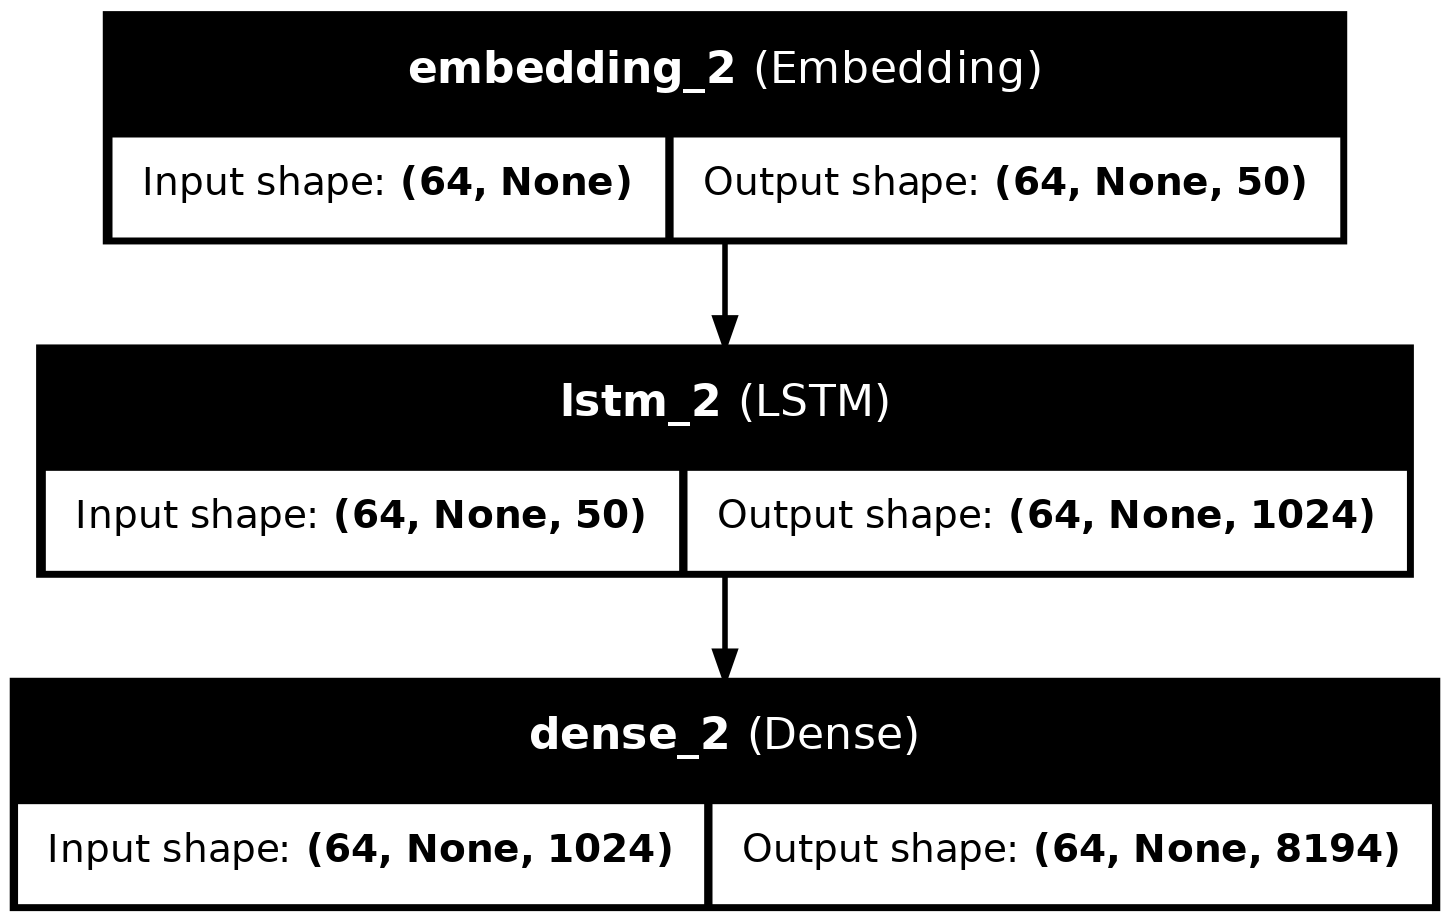

In [69]:
tf.keras.utils.plot_model(
    model,
    show_shapes=True,
    show_layer_names=True,
)

In [70]:
# Loss function
def loss(labels, logits):
    return tf.keras.losses.sparse_categorical_crossentropy(
        y_true=labels,
        y_pred=logits,
        from_logits=True
    )

# Compile the model
adam_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(
    optimizer=adam_optimizer,
    loss=loss
)

# Directory for checkpoints
checkpoint_dir = 'tmp/checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

# Checkpoint filename
checkpoint_prefix = os.path.join(checkpoint_dir, 'model.weights.h5')
checkpoint_prefix = os.path.join(checkpoint_dir, 'model_epoch_{epoch:02d}.weights.h5')

checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_prefix,
    save_best_only=True,
    save_weights_only=True,
    monitor='loss',
    mode='min',
    verbose=1
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='loss', patience=3, restore_best_weights=True
)


In [ ]:
EPOCHS = 80
history = model.fit(
    x=dataset,
    epochs=EPOCHS,
    callbacks=[
        checkpoint_cb, early_stopping
    ]
)


Epoch 1/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - loss: 7.4553
Epoch 1: loss improved from inf to 6.80265, saving model to tmp/checkpoints/model_epoch_01.weights.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 229ms/step - loss: 7.4242
Epoch 2/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - loss: 6.1907
Epoch 2: loss improved from 6.80265 to 6.19695, saving model to tmp/checkpoints/model_epoch_02.weights.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 225ms/step - loss: 6.1910
Epoch 3/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - loss: 6.1205
Epoch 3: loss improved from 6.19695 to 6.14868, saving model to tmp/checkpoints/model_epoch_03.weights.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 224ms/step - loss: 6.1218
Epoch 4/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - loss: 6.0983
Epoch 4: loss improved from 6.14868 to 6.09504, saving model to tmp/checkpoints/model_epoch_04.weights.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 231ms/step - loss: 6.0982
Epoch 5/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - loss: 5.9747
Epoch 5: loss improve

In [29]:
def render_training_history(training_history):
    loss = training_history.history['loss']
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.plot(loss, label='Training set')
    plt.legend()
    plt.grid(linestyle='--', linewidth=1, alpha=0.5)
    plt.show()

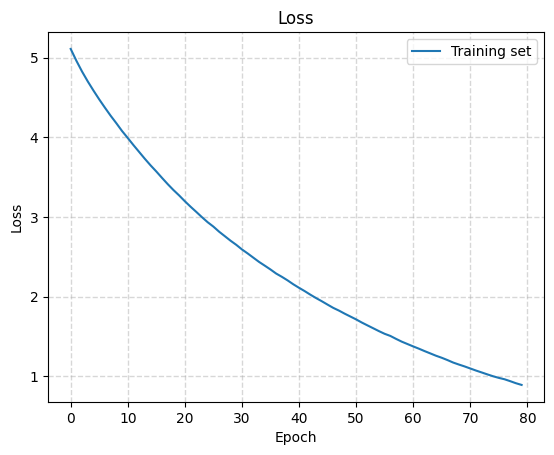

In [30]:
render_training_history(history)

# generate text

In [31]:
tf.train.latest_checkpoint(checkpoint_dir)
simplified_batch_size = 1

model = build_model(vocab_size, embedding_dim, rnn_units, batch_size=1)

model.load_weights('tmp/checkpoints/model_epoch_80.weights.h5')

model.build(tf.TensorShape([simplified_batch_size, None]))

In [ ]:
tf.train.latest_checkpoint(checkpoint_dir)
import glob

# Get list of all weight files
weight_files = glob.glob(os.path.join(checkpoint_dir, '*.weights.h5'))

if weight_files:
    latest = max(weight_files, key=os.path.getctime)  # or sort by name, etc.
    model.load_weights(latest)
    print(f"Loaded weights from: {latest}")
else:
    print("No weights file found. Using randomly initialized model.")

In [32]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (1, None, 300)         │     2,458,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (1, None, 1024)        │     5,427,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1, None, 8194)        │     8,398,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,284,250 (62.12 MB)

 Trainable params: 16,284,250 (62.12 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
def generate_text(model, start_string, num_generate=1000, temperature=1.0):
    # Tokenize the start string
    tokens = simple_tokenize(start_string)
    input_ids = [word_to_index.get(token, 0) for token in tokens]
    input_ids = tf.expand_dims(input_ids, 0)

    # Empty list to store generated tokens
    generated_tokens = []

    # Reset states for RNN layers if they are stateful
    for layer in model.layers:
        if hasattr(layer, 'reset_states'):
            layer.reset_states()

    for _ in range(num_generate):
        predictions = model(input_ids)
        # Remove batch dimension
        predictions = tf.squeeze(predictions, 0)

        # Use the last prediction
        predictions = predictions[-1:, :] / temperature
        predicted_id = tf.random.categorical(
            predictions,
            num_samples=1
        )[-1, 0].numpy()

        # Append the predicted token
        generated_tokens.append(predicted_id)

        # Update input_ids for next prediction
        input_ids = tf.expand_dims([predicted_id], 0)

    # Decode the generated tokens
    generated_text = ' '.join([index_to_word.get(i, "<OOV>") for i in generated_tokens])

    # Return the full text
    return start_string + generated_text

# Generate text with the model
print(generate_text(model, start_string="Sherlock: ", num_generate=500))

Sherlock: mary has turned it before , it was obvious to me that she must get away here , and he had gone . he was still with me on the line , for the cabs came on a very few feet , and the same thickness . but only as i learn the red - headed league ? ” “ if the ceiling was deadly one . it was a double line of tracks of a day , so that i have already noticed . an inspection . at last he hardly find a husband in his direction , and came back to my wife ’ s amazing powers in no easy and questioning that he was able to sell it , and mrs . st . clair was waiting . i tried to deal with me and forbidding her way up to them . what was this nocturnal expedition , and why i urged against him , but i was all sure of the _lone star_ of her father ’ s guilt ? ” “ i have sworn it out of any very paper but this morning , ” groaned our visitor . “ surely it is very ingenious , but you have hit upon . ” “ and of the name of lord st . simon , as i had hoped , was not so after a country then . a married

In [47]:
# Generate the text with default temperature (1.0).
print(generate_text(model, start_string=u"Sherlock: "))

Sherlock: “ one , sir , may have been of a man who is very far for me to be so as an actress myself . male costume is not the lad . it seemed funny that i heard his first more good things to go for me . i didn ’ t know what to say . i should not be , but i should be better able to know what long he may prove to me tell me whatever it ? ” “ i thank you that your assistant is always danger there . nothing . ” “ about the hour of this sinister matter was occurred to mr . lestrade as to turn my heart upon me . i would come by a glance that he had this evening , but to an end came away from having every morning , however , which looked better silently together , but there was no more than his deserts . this observation of his daily were asked his club , but not at least an hour or twelve , and my bedroom had been in china , and i could only see a hideous face which was even with a professional deep business which was within a note of a few hours to two years as usual feet upon me , while i 

In [ ]:
# Generate the text with higher temperature to get more unexpected results.
print(generate_text(model, start_string=u"Sherlock: ", temperature=1.5))

### Evaluation of the 1-layer LSTM Model with Glove Embeddings

Spelling accuracy function

In [50]:
!pip install pyspellchecker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 79.5 MB/s eta 0:00:00


In [51]:
from spellchecker import SpellChecker

In [35]:
def evaluate_spelling_accuracy(generated_text):

    # Initialize spell checker
    spell = SpellChecker(language='en')

    # Clean the text and split into words
    cleaned_text = re.sub(r'[^\w\s]', ' ', generated_text.lower())
    words = [word for word in cleaned_text.split() if word.strip()]

    words = [word for word in words if word.isalpha() and len(word) > 1]

    # Count total words
    total_words = len(words)

    if total_words == 0:
        return {
            "correct_words": 0,
            "incorrect_words": 0,
            "total_words": 0,
            "spelling_accuracy": 0.0,
            "most_common_incorrect": []
        }

    # Find misspelled words
    misspelled = spell.unknown(words)

    # Count correct words
    correct_words = total_words - len(misspelled)

    # Calculate spelling accuracy
    spelling_accuracy = (correct_words / total_words) * 100

    # Get most common incorrect words
    incorrect_counter = Counter(misspelled)
    most_common_incorrect = incorrect_counter.most_common(10)

    # Return metrics
    return {
        "correct_words": correct_words,
        "incorrect_words": len(misspelled),
        "total_words": total_words,
        "spelling_accuracy": spelling_accuracy,
        "most_common_incorrect": most_common_incorrect
    }

In [36]:
def analyze_text(text, original_prompt_length):
    # Analyze only the generated portion
    generated_text = text[original_prompt_length:]

    # Word diversity (higher = more diverse vocabulary)
    words = re.findall(r'\b\w+\b', generated_text.lower())
    word_diversity = len(set(words)) / len(words) if words else 0

    # Repetition rate (higher = more repetition)
    word_counts = Counter(words)
    repetitions = sum(count - 1 for count in word_counts.values())
    repetition_rate = repetitions / len(words) if words else 0

    # Average sentence length
    sentences = re.split(r'[.!?]+', generated_text)
    sentences = [s for s in sentences if s.strip()]
    avg_sentence_length = sum(len(s.split()) for s in sentences) / len(sentences) if sentences else 0

    # Spelling accuracy
    spelling_accuracy = evaluate_spelling_accuracy(generated_text)['spelling_accuracy']

    return {
        "word_diversity": word_diversity,
        "repetition_rate": repetition_rate,
        "avg_sentence_length": avg_sentence_length,
        "spelling_accuracy" : spelling_accuracy
    }

In [52]:
import re

start_string = "Sherlock Holmes looked at me with a smile. "
# Generate 5 samples for more reliable metrics
metrics = []
for _ in range(5):
    text = generate_text(model, start_string, 300, 1.0)
    metrics.append(analyze_text(text, len(start_string)))

# Average the metrics
results = {k: sum(m[k] for m in metrics)/len(metrics) for k in metrics[0]}

In [53]:
# Print the results
print(f"{'Temperature':<12} {'Word Diversity':<18} {'Repetition Rate':<18} {'Avg Sentence Length':<24} {'Spelling accuracy'}")
print("-" * 100)
temp = 1.0
print(f"{temp:<12} {results['word_diversity']:<18.3f} {results['repetition_rate']:<18.3f} {results['avg_sentence_length']:<24.3f} {results['spelling_accuracy']:0.2f}")

Temperature  Word Diversity     Repetition Rate    Avg Sentence Length      Spelling accuracy
----------------------------------------------------------------------------------------------------
1.0          0.593              0.407              19.034                   99.58


In [41]:
!pip install language-tool-python


In [44]:
import language_tool_python
import re

def evaluate_grammar_quality(generated_text):

    try:
        tool = language_tool_python.LanguageTool('en-GB')
    except:
        print("LanguageTool not available. Installing via pip...")
        import subprocess
        import sys
        subprocess.check_call([sys.executable, "-m", "pip", "install", "language-tool-python"])
        tool = language_tool_python.LanguageTool('en-GB')

    # Find grammar and spelling errors
    matches = tool.check(generated_text)

    # Count errors by category
    error_categories = Counter()
    for match in matches:
        error_categories[match.category] = error_categories.get(match.category, 0) + 1

    # Calculate word count
    words = re.findall(r'\b\w+\b', generated_text)
    word_count = len(words)

    # Calculate errors per 100 words
    errors_per_100_words = (len(matches) / max(1, word_count)) * 100

    results = {
        'total_errors': len(matches),
        'error_categories': dict(error_categories),
        'errors_per_100_words': errors_per_100_words,
        'word_count': word_count
    }

    return results

def merge_error_categories(error_cat_list):
    merged = Counter()
    for error_cat in error_cat_list:
        for category, count in error_cat.items():
            merged[category] += count

    # Calculate averages
    result = {category: count / len(error_cat_list) for category, count in merged.items()}
    return result


def run_evaluations(model, start_string, num_runs=5, num_tokens=300):
    run_results = []

    for run in range(1, num_runs + 1):
        print(f"  Run {run}/{num_runs}...")
        text = generate_text(model, start_string, num_tokens, 1.0)
        run_results.append(evaluate_grammar_quality(text))

    # Calculate averages across runs
    avg_results = {
        'total_errors': sum(r['total_errors'] for r in run_results) / num_runs,
        'errors_per_100_words': sum(r['errors_per_100_words'] for r in run_results) / num_runs,
        'word_count': sum(r['word_count'] for r in run_results) / num_runs,
        'error_categories': merge_error_categories([r['error_categories'] for r in run_results])
    }

    # Store individual runs for reference
    avg_results['individual_runs'] = run_results

    return avg_results

In [45]:
# Define temperatures to test
start_string = "Sherlock Holmes looked at the"

# Run the evaluations 5 times for each temperature
results = run_evaluations(model, start_string, num_runs=5, num_tokens=300)

  Run 1/5...
  Run 2/5...
  Run 3/5...
  Run 4/5...
  Run 5/5...


In [46]:
# Print results
print("\n===== AVERAGED RESULTS =====")
print(f"Average total errors: {results['total_errors']:.2f}")
print(f"Average errors per 100 words: {results['errors_per_100_words']:.2f}")
print(f"Average word count: {results['word_count']:.2f}")
print("Average error categories:")

# Sort categories by frequency for better readability
sorted_categories = sorted(
    results['error_categories'].items(),
    key=lambda x: x[1],
    reverse=True
)

for category, avg_count in sorted_categories:
    print(f"  - {category}: {avg_count:.2f}")


===== AVERAGED RESULTS =====
Average total errors: 61.80
Average errors per 100 words: 24.47
Average word count: 252.60
Average error categories:
  - TYPOGRAPHY: 36.00
  - TYPOS: 13.60
  - CASING: 10.80
  - MISC: 0.60
  - GRAMMAR: 0.20
  - PUNCTUATION: 0.20
  - STYLE: 0.20
  - REDUNDANCY: 0.20


In [ ]:
import seaborn as sns
import pandas as pd

def grammar_results_token():

    # Temperature settings
    temps = [0.2, 0.5, 0.7, 1.0, 1.3, 1.7, 2.0]
    x = np.arange(len(temps))
    bar_width = 0.35

    # Averaged error data for each checkpoint
    ckpt80_avg_errors = [
        {'PUNCTUATION': 2.20, 'REPETITIONS_STYLE': 0.40},
        {'PUNCTUATION': 1.80, 'GRAMMAR': 0.40, 'COLLOCATIONS': 0.20},
        { 'PUNCTUATION': 2.80, 'GRAMMAR': 1.00, 'TYPOGRAPHY': 0.20},
        { 'PUNCTUATION': 4.20, 'GRAMMAR': 1.40, 'MISC': 0.40, 'CONFUSED_WORDS': 0.20, 'TYPOGRAPHY': 0.20},
        { 'PUNCTUATION': 5.40, 'MISC': 1.20, 'GRAMMAR': 1.20, 'CASING': 0.60, 'TYPOGRAPHY': 0.20},
        { 'PUNCTUATION': 5.40, 'GRAMMAR': 2.80, 'CASING': 1.60, 'MISC': 0.80, 'TYPOGRAPHY': 0.60, 'CONFUSED_WORDS': 0.20, 'AMERICAN_ENGLISH': 0.20},
        { 'PUNCTUATION': 4.00, 'GRAMMAR': 2.40, 'CASING': 1.40, 'MISC': 0.40, 'STYLE': 0.20, 'TYPOGRAPHY': 0.20},
    ]

    ckpt40_avg_errors = [
        {'PUNCTUATION': 2.20,  'GRAMMAR': 0.20},
        {'PUNCTUATION': 3.20,  'GRAMMAR': 0.60},
        { 'PUNCTUATION': 2.40, 'GRAMMAR': 1.20, 'MISC': 0.80, 'CONFUSED_WORDS': 0.40, 'AMERICAN_ENGLISH': 0.20},
        { 'PUNCTUATION': 4.20, 'GRAMMAR': 2.00, 'MISC': 0.80, 'CASING': 0.40, 'REDUNDANCY': 0.20, 'CONFUSED_WORDS': 0.20, 'BRE_STYLE_OXFORD_SPELLING': 0.20},
        { 'PUNCTUATION': 4.20, 'GRAMMAR': 2.20, 'CASING': 0.60, 'MISC': 0.60, 'AMERICAN_ENGLISH': 0.40, 'TYPOGRAPHY': 0.40, 'CONFUSED_WORDS': 0.20, 'COLLOCATIONS': 0.20},
        { 'PUNCTUATION': 4.00, 'MISC': 1.80, 'GRAMMAR': 1.20, 'CASING': 1.00, 'TYPOGRAPHY': 0.60, 'STYLE': 0.20},
        { 'PUNCTUATION': 3.80, 'GRAMMAR': 1.60, 'CASING': 1.20, 'MISC': 0.60, 'TYPOGRAPHY': 0.20, 'COLLOCATIONS': 0.20, 'CONFUSED_WORDS': 0.20},
    ]

    # Get all unique categories from both checkpoints
    all_categories = sorted(set(k for d in ckpt80_avg_errors + ckpt40_avg_errors for k in d.keys()))

    # Assign colors to categories using a consistent color map
    color_map = plt.cm.get_cmap('tab20', len(all_categories))
    category_colors = {cat: color_map(i) for i, cat in enumerate(all_categories)}

    # Build matrix for plotting
    def build_matrix(errors_list):
        matrix = {cat: [] for cat in all_categories}
        for entry in errors_list:
            for cat in all_categories:
                matrix[cat].append(entry.get(cat, 0))
        return matrix

    matrix_80 = build_matrix(ckpt80_avg_errors)
    matrix_40 = build_matrix(ckpt40_avg_errors)

    # Plot
    fig, ax = plt.subplots(figsize=(12, 7))
    bottom80 = np.zeros(len(temps))
    bottom40 = np.zeros(len(temps))

    for cat in all_categories:
        vals80 = matrix_80[cat]
        vals40 = matrix_40[cat]
        color = category_colors[cat]

        ax.bar(x - bar_width/2, vals80, bar_width, label=cat if cat not in ax.get_legend_handles_labels()[1] else "", color=color, bottom=bottom80)
        ax.bar(x + bar_width/2, vals40, bar_width, color=color, bottom=bottom40)

        bottom80 += np.array(vals80)
        bottom40 += np.array(vals40)

    ax.set_title("Average Error Categories by Temperature (Stacked Bars)")
    ax.set_xlabel("Temperature")
    ax.set_ylabel("Average Number of Errors")
    ax.set_xticks(x)
    ax.set_xticklabels([str(t) for t in temps])
    ax.legend(title="Error Categories", bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True)

    plt.tight_layout()
    plt.show()

grammar_results_token()